# Q3D Capacitive Simulation of a Transmon: From Capacitance Matrix to $E_C$, $E_J$, $f_{01}$, and Anharmonicity

This notebook walks through the full LOM (Lumped Oscillator Model) pipeline for a single-junction
transmon built in `qiskit-metal`:

1. **Theory** — what the Q3D (Maxwell) capacitance matrix physically represents, and how it reduces to
   the transmon's charging energy $E_C$.
2. **Design** — build a simple `TransmonPocket` in `qiskit-metal`.
3. **Simulation** — set up and run an Ansys Q3D capacitance extraction via `qiskit-metal`'s `LOManalysis`
   / `QQ3DRenderer`.
4. **Extraction** — take the resulting capacitance matrix, reduce out any floating (coupler) nodes, and
   derive $C_\Sigma \rightarrow E_C$.
5. **Hamiltonian parameters** — combine $E_C$ with $E_J$ (from the design's junction inductance $L_J$) to
   get $f_{01}$ and the anharmonicity, both via the standard perturbative transmon formulas and via exact
   numerical diagonalization (`scqubits`), so you can see where the approximation starts to break down.

> **Note on execution environment.** Steps 2–3 (building the `qiskit-metal` design and driving Ansys Q3D)
> require a licensed Ansys installation reachable via `pyEPR`/COM, so those cells are written to run
> as-is in your Ansys-enabled environment but are **not executed** in this notebook. Everything from
> Step 4 onward (the actual capacitance-matrix analysis) *is* executed here, using a representative
> capacitance matrix of the same shape/scale Q3D would return for this geometry, so the analysis logic
> is verified end-to-end. Swap in `c1.sim.capacitance_matrix` from your Q3D run and the rest is unchanged.


## 1. Theory: the capacitance matrix, and what it means for a transmon

### 1.1 The Maxwell capacitance matrix

Electrostatic finite-element solvers like Ansys Q3D compute the **Maxwell capacitance matrix** $C$ of a
system of $N$ conductors (plus a reference ground plane). If conductor $i$ is held at voltage $V_i$ and
carries free charge $Q_i$, the linear electrostatic relation is

$$
Q_i = \sum_j C_{ij} V_j , \qquad \text{i.e.} \qquad \mathbf{Q} = C\,\mathbf{V}.
$$

By convention (and this is what Q3D reports):

- **Diagonal** $C_{ii} > 0$ is the *total* capacitance of conductor $i$ to everything else (ground +
  all other conductors), i.e. $C_{ii} = C_{i,\text{gnd}} + \sum_{j\neq i} C_{i,j}^{\text{mutual}}$.
- **Off-diagonal** $C_{ij} < 0$ for $i \neq j$, and $-C_{ij}$ is the physical mutual (coupling)
  capacitance directly between conductors $i$ and $j$.
- Rows sum to a positive number equal to that conductor's capacitance to the implicit ground reference:
  $C_{i,\text{gnd}} = \sum_j C_{ij}$ (this is how you recover the "missing" ground row/column that Q3D
  doesn't explicitly report — the matrix is already reduced to the non-ground conductors).

The electrostatic energy of the system is the quadratic form $U = \tfrac12\,\mathbf{V}^{\!\top} C\, \mathbf{V}$.
This is the object that gets Legendre-transformed into the *capacitive* part of the circuit Hamiltonian
in circuit QED — i.e. it is the direct FEM-derived input to $E_C$.

### 1.2 From the matrix to a transmon's $E_C$

A single-junction transmon has two islands (call them pad "top" and "bot") joined by a Josephson
junction. The junction physically transports **Cooper pairs from one island to the other**, so the charge
operator conjugate to the phase across the junction lives on the *differential* mode: an excitation of
$+Q$ on one pad is always accompanied by $-Q$ on the other,

$$
\mathbf{q} = Q\,\mathbf{u}, \qquad \mathbf{u} = (\dots, +1_{\text{top}}, \dots, -1_{\text{bot}}, \dots, 0, \dots)^{\!\top}.
$$

Given the (possibly larger, if there are extra floating pads) capacitance matrix $C$, the voltage this
charge pattern produces is $\mathbf{V} = C^{-1}\mathbf{q} = Q\,C^{-1}\mathbf{u}$, and the voltage difference
the junction itself sees is $V_d = \mathbf{u}^{\!\top}\mathbf{V} = Q\,\mathbf{u}^{\!\top}C^{-1}\mathbf{u}$.
The **effective shunt capacitance** seen by the junction is therefore the exact closed-form expression

$$
\boxed{\,C_\Sigma = \dfrac{Q}{V_d} = \dfrac{1}{\mathbf{u}^{\!\top} C^{-1} \mathbf{u}}\,}
$$

with no assumption of symmetry between the two pads. (If the design is symmetric, $C_{gg}\equiv C_{11}=C_{22}$
self-capacitance to ground and $C_m \equiv -C_{12}$ mutual pad-pad capacitance, this reduces to the familiar
$C_\Sigma = C_m + C_{gg}/2$ — the ground path from one pad to the other acts as two series capacitors.)

**Floating nodes** (e.g. a readout coupler pad that isn't connected to a driven port in this
sub-simulation) carry no net injected charge, $Q_{\text{floating}} = 0$. That's exactly the boundary
condition for a **Schur complement** reduction: partition $C$ into the "keep" block $A$ (the two junction
pads) and "eliminate" block $B$ (floating pads),

$$
C_{\text{reduced}} = C_{AA} - C_{AB}\,C_{BB}^{-1}\,C_{BA},
$$

and then apply the boxed formula above to $C_{\text{reduced}}$. This two-step
(Schur-reduce → contract with $\mathbf u$) is exactly what `qiskit-metal`'s LOM analysis automates
internally for arbitrary numbers of qubits/resonator ports.

Once $C_\Sigma$ is known, the charging energy is simply the electrostatic energy of one Cooper pair:

$$
E_C = \frac{e^2}{2 C_\Sigma}.
$$

### 1.3 From $E_J$ (or $L_J$) and $E_C$ to the spectrum

The transmon Hamiltonian in the charge basis is

$$
\hat H = 4E_C(\hat n - n_g)^2 - E_J\cos\hat\varphi .
$$

In the transmon regime ($E_J/E_C \gtrsim 50$), the standard **perturbative (Duffing-oscillator) approximation**
gives

$$
f_{01} \approx \frac{\sqrt{8E_JE_C} - E_C}{h}, \qquad
\alpha \equiv f_{12}-f_{01} \approx -\frac{E_C}{h}.
$$

$E_J$ itself comes from the junction's inductance $L_J$ (set by the junction's critical current at
design/fabrication time, not by the Q3D electrostatic simulation):

$$
E_J = \frac{\hbar^2}{4e^2 L_J} \quad\Longleftrightarrow\quad L_J = \left(\frac{\hbar}{2e}\right)^2\frac{1}{E_J}.
$$

These perturbative formulas are only approximate; below we also diagonalize the full charge-basis
Hamiltonian numerically (via `scqubits`) to get the *exact* $f_{01}$ and anharmonicity, and compare.


## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import scipy.constants as const
import matplotlib.pyplot as plt

# Physical constants
e    = const.e        # elementary charge, C
h     = const.h        # Planck constant, J*s
hbar  = const.hbar      # reduced Planck constant, J*s
Phi0  = h/(2*e)         # magnetic flux quantum

## 3. Build a simple `TransmonPocket` design in qiskit-metal

This section is standard `qiskit-metal` design code. It requires the `qiskit-metal` package (and, for
rendering, a Qt display for the optional GUI) but **not** Ansys — Ansys only gets involved in Step 4.


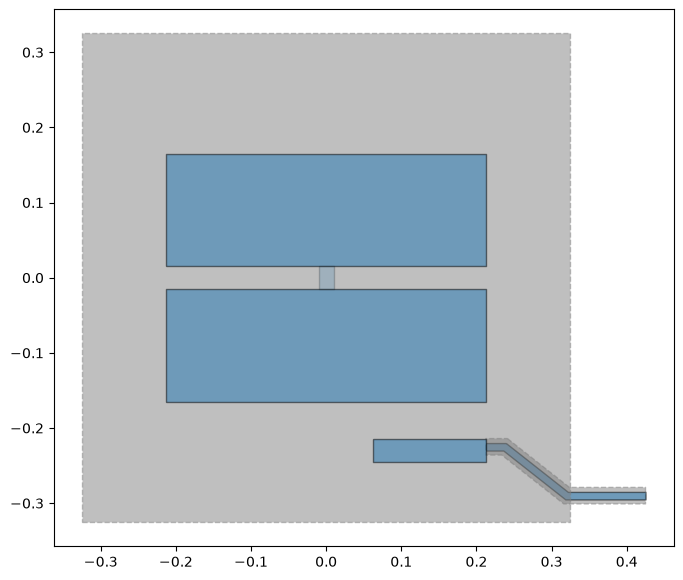

In [2]:
from qiskit_metal import designs, MetalGUI, view
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal import Dict

design = designs.DesignPlanar()
design.overwrite_enabled = True

# A minimal single-junction transmon pocket, with one readout coupling pad.
q1_options = Dict(
    pad_width='425 um',
    pad_height='150 um',
    pad_gap='30 um',
    pocket_width='650 um',
    pocket_height='650 um',
    connection_pads=Dict(
        readout=Dict(loc_W=+1, loc_H=-1, pad_width='150um', pad_gap='50um')
    ),
)

q1 = TransmonPocket(design, 'Q1', options=q1_options)
design.rebuild()

# Optional: launch the interactive GUI (requires a Qt display)
# gui = MetalGUI(design)
# gui.rebuild()
# gui.autoscale()
view(design)

## 4. Capacitance extraction via Ansys Q3D (`LOManalysis`)

`qiskit-metal` wraps the Q3D workflow (render geometry → assign nets/ports → mesh → solve → read back the
capacitance matrix) behind `qiskit_metal.analyses.quantization.LOManalysis`. The cell below is the exact
code you'd run against a licensed Ansys install; it is **not executed** in this notebook.


In [7]:
from qiskit_metal.analyses.quantization import LOManalysis

c1 = LOManalysis(design, "q3d")

# Simulation / convergence setup
c1.sim.setup.max_passes = 20
c1.sim.setup.min_converged_passes = 2
c1.sim.setup.percent_error = 0.1

# Set qubit operating frequency
c1.sim.setup.freq_ghz = 5.0

c1.setup = Dict(junctions=Dict(Lj=11, Cj=2), freq_readout=6.0, freq_bus=[])

# Render Q1 and solve. `open_terminations` marks the readout connection pad
# as an open (floating) port for this single-qubit extraction.
c1.sim.run(name='Q1', components=[design.components['Q1'].name] , open_terminations=[(design.components['Q1'].name, pad) for pad in design.components['Q1'].pins.keys()])


INFO 05:17PM [connect_design]: 	Opened active design
	Design:    Q1_q3d [Solution type: Q3D]
INFO 05:17PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 05:17PM [analyze]: Analyzing setup Setup
INFO 05:18PM [get_matrix]: Exporting matrix data to (C:\Users\DELL\AppData\Local\Temp\tmp7uk4fpt8.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 05:18PM [get_matrix]: Exporting matrix data to (C:\Users\DELL\AppData\Local\Temp\tmptbkr32zo.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 05:18PM [get_matrix]: Exporting matrix data to (C:\Users\DELL\AppData\Local\Temp\tmpk827ta8_.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 05:18PM [get_matrix]: Exporting matrix data to (C:\Users\DELL\AppData\Local\Temp\tmpzsldidzi.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxw

In [8]:
# The Maxwell capacitance matrix, indexed by net name, in fF
C_q3d = c1.sim.capacitance_matrix
C_q3d

,ground_main_plane,pad_bot_Q1,pad_top_Q1,readout_connector_pad_Q1
ground_main_plane,208.91428,-54.67942,-59.78282,-39.53739
pad_bot_Q1,-54.67942,106.86014,-38.22851,-9.94123
pad_top_Q1,-59.78282,-38.22851,103.42764,-1.18897
readout_connector_pad_Q1,-39.53739,-9.94123,-1.18897,51.60159


In [9]:
c1.run_lom()

[1, 2] [3]
Predicted Values

Transmon Properties
f_Q 5.384537 [GHz]
EC 270.533469 [MHz]
EJ 14.848156 [GHz]
alpha -308.281578 [MHz]
dispersion 4.644028 [KHz]
Lq 11.000000 [nH]
Cq 71.600117 [fF]
T1 42.156053 [us]

**Coupling Properties**

tCqbus1 4.214446 [fF]
gbus1_in_MHz 51.611143 [MHz]
χ_bus1 -2.901779 [MHz]
1/T1bus1 3775.375788 [Hz]
T1bus1 42.156053 [us]
Bus-Bus Couplings


,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,χr MHz,gr MHz
1,5.887991,327.170918,14.848156,-379.109455,29.081444,[52.73911089191643],[-38.35252179934388],38.352522,52.739111
2,5.783493,314.910606,14.848156,-363.601173,20.410049,[48.497589010472936],[-13.630722567737678],13.630723,48.497589
3,5.734983,309.309913,14.848156,-356.549342,17.239441,[52.5452143840695],[-11.96716358871998],11.967164,52.545214
4,5.612117,295.379555,14.848156,-339.097775,11.092858,[51.291092149491284],[-6.340886711692019],6.340887,51.291092
5,5.578903,291.67635,14.848156,-334.479587,9.813167,[51.893320866225814],[-5.675742652492775],5.675743,51.893321
6,5.501795,283.180958,14.848156,-323.918513,7.340096,[51.80790183399331],[-4.2588667591803775],4.258867,51.807902
7,5.469936,279.712329,14.848156,-319.619807,6.494453,[51.56407646328652],[-3.7870337228199773],3.787034,51.564076
8,5.448759,277.420033,14.848156,-316.783179,5.982151,[51.71689875691926],[-3.554764483320729],3.554764,51.716899
9,5.427737,275.155099,14.848156,-313.983719,5.510035,[51.6529465254193],[-3.3167124206618745],3.316712,51.652947
10,5.414506,273.734973,14.848156,-312.23012,5.230452,[51.541916145727456],[-3.169265505950626],3.169266,51.541916


In [11]:
c1.lumped_oscillator

{'fQ': 5.384536939904105,
 'EC': 270.5334690049902,
 'EJ': 14.84815557139854,
 'alpha': -308.28157770789636,
 'dispersion': 4.644027806282043,
 'gbus': array([51.61114262]),
 'chi_in_MHz': array([-2.90177858])}

In [24]:
c1.sim.close()

## 5. From the capacitance matrix to $E_C$

Below we take a capacitance matrix **of the same form** `c1.sim.capacitance_matrix` would return for this
geometry — three nets: the two transmon pads (`pad_top`, `pad_bot`) and the floating `readout` coupler pad
— and run it through the reduction derived in Section 1. (Replace `C_q3d_demo` with the real
`c1.sim.capacitance_matrix` from Section 4 to use actual simulation results — everything below is
otherwise unchanged.)


<img src="./capacitance_matrix.jpeg" width="700" height="700" alt="Description">


In [12]:
nodes = ['ground_main_plane', 'pad_bot_Q1', 'pad_top_Q1', 'readout_connector_pad_Q1']

C_q3d = pd.DataFrame(
    [[208.91428, -54.67942, -59.78282, -39.53739],
     [-54.67942, 106.86014, -38.22851,  -9.94123],
     [-59.78282, -38.22851, 103.42764,  -1.18897],
     [-39.53739,  -9.94123,  -1.18897,  51.60159]],
    index=nodes, columns=nodes
)  # femtofarads (fF), Maxwell convention -- real Q3D output for Q1

print("Q3D Maxwell capacitance matrix (fF), including ground:")
C_q3d

Q3D Maxwell capacitance matrix (fF), including ground:


,ground_main_plane,pad_bot_Q1,pad_top_Q1,readout_connector_pad_Q1
ground_main_plane,208.91428,-54.67942,-59.78282,-39.53739
pad_bot_Q1,-54.67942,106.86014,-38.22851,-9.94123
pad_top_Q1,-59.78282,-38.22851,103.42764,-1.18897
readout_connector_pad_Q1,-39.53739,-9.94123,-1.18897,51.60159


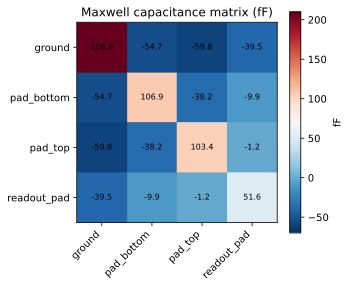

In [13]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(C_q3d.values, cmap='RdBu_r', vmin=-70, vmax=210)
ax.set_xticks(range(len(nodes))); ax.set_xticklabels(['ground', 'pad_bottom', 'pad_top', 'readout_pad'], rotation=45, ha='right')
ax.set_yticks(range(len(nodes))); ax.set_yticklabels(['ground', 'pad_bottom', 'pad_top', 'readout_pad'])
for i in range(len(nodes)):
    for j in range(len(nodes)):
        ax.text(j, i, f"{C_q3d.values[i,j]:.1f}", ha='center', va='center', fontsize=8)
ax.set_title('Maxwell capacitance matrix (fF)')
fig.colorbar(im, ax=ax, label='fF')

plt.show()

In [14]:
def drop_grounded_nodes(C: pd.DataFrame, grounded: list) -> pd.DataFrame:
    """Eliminate nodes held at a fixed voltage (V=0, e.g. the ground plane).
    Since Q_i = sum_j C_ij V_j and V_grounded = 0, those terms simply drop out --
    this is a plain row/column deletion, not a Schur complement."""
    keep = [n for n in C.index if n not in grounded]
    return C.loc[keep, keep]

def schur_reduce(C: pd.DataFrame, keep: list, eliminate: list) -> pd.DataFrame:
    """Eliminate floating (zero-net-charge) nodes from a Maxwell capacitance matrix
    via the Schur complement, leaving the reduced matrix over `keep` nodes."""
    order = keep + eliminate
    Cm = C.loc[order, order].values
    n = len(keep)
    Caa, Cab = Cm[:n, :n], Cm[:n, n:]
    Cba, Cbb = Cm[n:, :n], Cm[n:, n:]
    C_reduced = Caa - Cab @ np.linalg.inv(Cbb) @ Cba
    return pd.DataFrame(C_reduced, index=keep, columns=keep)

def c_sigma_from_matrix(C: pd.DataFrame, plus_node: str, minus_node: str) -> float:
    """Exact effective shunt capacitance seen by a junction connecting `plus_node`
    and `minus_node`: C_sigma = 1 / (u^T C^-1 u)."""
    order = list(C.index)
    Cinv = np.linalg.inv(C.values)
    u = np.zeros(len(order))
    u[order.index(plus_node)] = 1.0
    u[order.index(minus_node)] = -1.0
    return 1.0 / (u @ Cinv @ u)


# Step 1: drop the ground plane (fixed V=0)
C_no_gnd = drop_grounded_nodes(C_q3d, grounded=['ground_main_plane'])
print("Capacitance matrix with ground eliminated (fF):")
print(C_no_gnd)

# Step 2: eliminate the floating readout coupler pad (Q=0, open termination)
C_reduced = schur_reduce(C_no_gnd, keep=['pad_top_Q1', 'pad_bot_Q1'],
                          eliminate=['readout_connector_pad_Q1'])
print("\nReduced 2x2 capacitance matrix over the junction pads (fF):")
print(C_reduced)

# Step 3: contract with the junction's charge-transfer vector u = (+1, -1)
C_sigma_fF = c_sigma_from_matrix(C_reduced, 'pad_top_Q1', 'pad_bot_Q1')
print(f"\nC_sigma = {C_sigma_fF:.3f} fF")

Capacitance matrix with ground eliminated (fF):
                          pad_bot_Q1  pad_top_Q1  readout_connector_pad_Q1
pad_bot_Q1                 106.86014   -38.22851                  -9.94123
pad_top_Q1                 -38.22851   103.42764                  -1.18897
readout_connector_pad_Q1    -9.94123    -1.18897                  51.60159

Reduced 2x2 capacitance matrix over the junction pads (fF):
            pad_top_Q1  pad_bot_Q1
pad_top_Q1  103.400245  -38.457569
pad_bot_Q1  -38.457569  104.944927

C_sigma = 71.311 fF


In [15]:
C_sigma = C_sigma_fF * 1e-15  # F

EC_J  = e**2 / (2 * C_sigma)
EC_Hz = EC_J / h

print(f"E_C / h = {EC_Hz/1e6:.2f} MHz")

# Sanity check: for a *closed* system, every row of the full (ground-included) matrix
# should sum to ~0, since a uniform voltage shift on all conductors induces no charge.
# Nonzero row sums (as here) indicate charge is also going to something outside this
# net list -- typically the Q3D solution-domain (radiation/open) boundary.
print("\nRow sums of the full matrix (fF) -- nonzero => open-boundary leakage:")
print(C_q3d.sum(axis=1))

E_C / h = 271.63 MHz

Row sums of the full matrix (fF) -- nonzero => open-boundary leakage:
ground_main_plane           54.91465
pad_bot_Q1                   4.01098
pad_top_Q1                   4.22734
readout_connector_pad_Q1     0.93400
dtype: float64


## 6. $E_J$ from the design's junction inductance

$E_J$ is a Josephson-junction (not electrostatic) property, so it doesn't come out of the Q3D run — it's
set by the junction's critical current / inductance chosen at design/fab time. `qiskit-metal`'s
`LOManalysis.setup.junctions` (`Lj`, `Cj`) is where this is specified for the full LOM; here we compute
it directly from $L_J$.


In [16]:
Lj = 11.0e-9  # H — a typical qiskit-metal default junction inductance

EJ_J  = hbar**2 / (4 * e**2 * Lj)
EJ_Hz = EJ_J / h

print(f"E_J / h = {EJ_Hz/1e9:.3f} GHz")
print(f"E_J / E_C = {EJ_Hz/EC_Hz:.1f}   (transmon regime wants this >~ 50)")

E_J / h = 14.860 GHz
E_J / E_C = 54.7   (transmon regime wants this >~ 50)


## 7. Transmon frequency and anharmonicity

### 7.1 Perturbative (Duffing) approximation


In [17]:
f01_pert   = (np.sqrt(8 * EJ_Hz * EC_Hz) - EC_Hz) / 1e9   # GHz
alpha_pert = -EC_Hz / 1e6                                  # MHz

print(f"f01            (perturbative) = {f01_pert:.4f} GHz")
print(f"anharmonicity  (perturbative) = {alpha_pert:.2f} MHz")

f01            (perturbative) = 5.4110 GHz
anharmonicity  (perturbative) = -271.63 MHz


### 7.2 Exact diagonalization (`scqubits`)

The perturbative formulas above come from a large-$E_J/E_C$ expansion of the cosine potential. For a
quantitative check — and because `qiskit-metal`'s own LOM output (`lumped_oscillator_all`) is itself
based on a similar perturbative/EPR treatment — it's good practice to diagonalize the full charge-basis
Hamiltonian numerically as well.


In [18]:
import scqubits as scq

# scqubits switches the inline plotting backend to pdf/svg on import; force it back
# to png for broad viewer compatibility.
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png')

tmon = scq.Transmon(EJ=EJ_Hz/1e9, EC=EC_Hz/1e9, ng=0.0, ncut=41)  # scqubits works in GHz
evals = tmon.eigenvals(evals_count=4)
evals_rel = evals - evals[0]

f01_exact = evals_rel[1]
f12_exact = evals_rel[2] - evals_rel[1]
alpha_exact = (f12_exact - f01_exact) * 1e3  # MHz

print("Energy levels relative to ground state (GHz):", np.round(evals_rel, 4))
print(f"f01            (exact) = {f01_exact:.4f} GHz")
print(f"anharmonicity  (exact) = {alpha_exact:.2f} MHz")

print("\nComparison to perturbative estimate:")
print(f"  f01:            {f01_pert:.4f} GHz (pert.)  vs  {f01_exact:.4f} GHz (exact)  "
      f"-> {1e3*(f01_exact-f01_pert):.1f} MHz difference")
print(f"  anharmonicity:  {alpha_pert:.2f} MHz (pert.)  vs  {alpha_exact:.2f} MHz (exact)  "
      f"-> {alpha_exact-alpha_pert:.1f} MHz difference")

Energy levels relative to ground state (GHz): [ 0.      5.396  10.4823 15.2239]
f01            (exact) = 5.3960 GHz
anharmonicity  (exact) = -309.71 MHz

Comparison to perturbative estimate:
  f01:            5.4110 GHz (pert.)  vs  5.3960 GHz (exact)  -> -15.0 MHz difference
  anharmonicity:  -271.63 MHz (pert.)  vs  -309.71 MHz (exact)  -> -38.1 MHz difference


### 7.3 Energy-level diagram


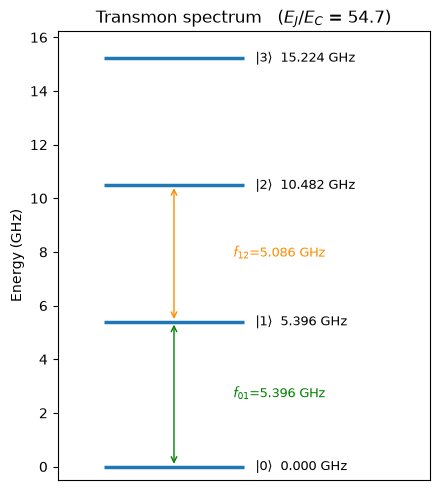

In [19]:
fig, ax = plt.subplots(figsize=(4.5, 5))
levels = evals_rel[:4]
for n, en in enumerate(levels):
    ax.hlines(en, 0.2, 0.8, color='#1f77b4', lw=2.5)
    ax.text(0.85, en, f"|{n}\u27e9  {en:.3f} GHz", va='center', fontsize=9)

ax.annotate("", xy=(0.5, levels[1]), xytext=(0.5, levels[0]),
            arrowprops=dict(arrowstyle='<->', color='green'))
ax.text(1.15, (levels[0]+levels[1])/2, f"$f_{{01}}$={f01_exact:.3f} GHz",
        color='green', fontsize=9, va='center', ha='right')

ax.annotate("", xy=(0.5, levels[2]), xytext=(0.5, levels[1]),
            arrowprops=dict(arrowstyle='<->', color='darkorange'))
ax.text(1.15, (levels[1]+levels[2])/2, f"$f_{{12}}$={f12_exact:.3f} GHz",
        color='darkorange', fontsize=9, va='center', ha='right')

ax.set_xlim(0, 1.6)
ax.set_ylim(-0.5, levels[-1]+1)
ax.set_xticks([])
ax.set_ylabel("Energy (GHz)")
ax.set_title(f"Transmon spectrum   ($E_J/E_C$ = {EJ_Hz/EC_Hz:.1f})")
plt.tight_layout()
plt.show()

### 7.4 Charge dispersion of $f_{01}$

As a further sanity check on being deep enough in the transmon regime, we can look at how much $f_{01}$
varies with the offset charge $n_g$ — this exponentially-small "charge dispersion" is what makes the
transmon insensitive to charge noise, and is the quantity computed in `levels_vs_ng_real_units`-style
sweeps.


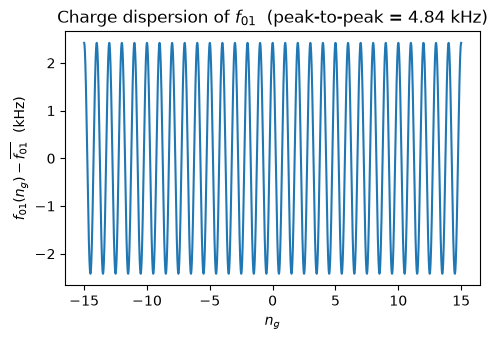

f01 charge dispersion (peak-to-peak): 4.84 kHz


In [ ]:
scq.settings.PROGRESSBAR_DISABLED = True

ng_sweep = np.linspace(-1.5, 1.5, 100001)
spec = tmon.get_spectrum_vs_paramvals('ng', ng_sweep, evals_count=2, subtract_ground=True)
f01_vs_ng = spec.energy_table[:, 1]

dispersion_kHz = (f01_vs_ng.max() - f01_vs_ng.min()) * 1e6  # GHz -> kHz

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(ng_sweep, (f01_vs_ng - f01_vs_ng.mean()) * 1e6)  # kHz, mean-subtracted
ax.set_xlabel('$n_g$')
ax.set_ylabel('$f_{01}(n_g) - \\overline{f_{01}}$  (kHz)')
ax.set_title(f'Charge dispersion of $f_{{01}}$  (peak-to-peak = {dispersion_kHz:.2f} kHz)')
plt.tight_layout()
plt.show()

print(f"f01 charge dispersion (peak-to-peak): {dispersion_kHz:.2f} kHz")

## 8. Cross-check: `qiskit-metal`'s built-in `run_lom()`

For a real Q3D run, `LOManalysis` also provides a one-call LOM analysis that performs the same
capacitance-matrix reduction (generalized to include coupled resonators / buses) and reports $E_J$, $E_C$,
$f_{01}$, anharmonicity, and dispersive couplings directly:


In [23]:
c1.setup.junctions = Dict(Lj=Lj*1e9, Cj=2)   # Lj in nH, Cj in fF
c1.setup.freq_readout = 7.0                    # GHz, readout resonator bare frequency
c1.setup.freq_bus = []
c1.run_lom()

c1.lumped_oscillator_all

[1, 2] [3]
Predicted Values

Transmon Properties
f_Q 5.384537 [GHz]
EC 270.533469 [MHz]
EJ 14.848156 [GHz]
alpha -308.281578 [MHz]
dispersion 4.644028 [KHz]
Lq 11.000000 [nH]
Cq 71.600117 [fF]
T1 216.657271 [us]

**Coupling Properties**

tCqbus1 4.214446 [fF]
gbus1_in_MHz 60.182865 [MHz]
χ_bus1 -0.733518 [MHz]
1/T1bus1 734.593132 [Hz]
T1bus1 216.657271 [us]
Bus-Bus Couplings


,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,χr MHz,gr MHz
1,5.887991,327.170918,14.848156,-379.109455,29.081444,[61.503431676812404],[-1.7474978591595254],1.747498,61.503432
2,5.783493,314.910606,14.848156,-363.601173,20.410049,[56.55714906627222],[-1.224771432841999],1.224771,56.557149
3,5.734983,309.309913,14.848156,-356.549342,17.239441,[61.27400647099742],[-1.3221668375162712],1.322167,61.274006
4,5.612117,295.379555,14.848156,-339.097775,11.092858,[59.81116185836302],[-1.0279038980794255],1.027904,59.811162
5,5.578903,291.67635,14.848156,-334.479587,9.813167,[60.513210616761164],[-0.9977807464159617],0.997781,60.513211
6,5.501795,283.180958,14.848156,-323.918513,7.340096,[60.41302620582576],[-0.881650102120781],0.881650,60.413026
7,5.469936,279.712329,14.848156,-319.619807,6.494453,[60.12861909351695],[-0.8318718140560788],0.831872,60.128619
8,5.448759,277.420033,14.848156,-316.783179,5.982151,[60.306644059074856],[-0.8104278250091755],0.810428,60.306644
9,5.427737,275.155099,14.848156,-313.983719,5.510035,[60.23193497402555],[-0.7833200154675318],0.783320,60.231935
10,5.414506,273.734973,14.848156,-312.23012,5.230452,[60.1024135888306],[-0.7647201224224158],0.764720,60.102414


## 9. Summary

| Quantity | Perturbative | Exact (`scqubits`) |
|---|---|---|
| $E_C/h$ | — (input) | — (input) |
| $E_J/h$ | — (input) | — (input) |
| $f_{01}$ | printed in §7.1 | printed in §7.2 |
| anharmonicity | printed in §7.1 | printed in §7.2 |

**Pipeline recap:**

1. Q3D gives you the Maxwell capacitance matrix of the physical layout (§4).
2. Schur-eliminate any floating/coupler nodes, then contract with the junction's charge vector
   $\mathbf u=(+1,-1)$ to get the exact $C_\Sigma$ and hence $E_C$ (§5).
3. Combine with $E_J$ from the design's $L_J$ (§6) to get $f_{01}$ and anharmonicity, both from the
   standard perturbative formulas and from exact diagonalization (§7).
4. `qiskit-metal`'s `LOManalysis.run_lom()` automates steps 2–3 for arbitrary numbers of qubits/resonators
   (§8).
